<a href="https://colab.research.google.com/github/ashel1307/Artificial_Intelligence_Lab_SE_A_55/blob/master/DS_EXPERIMENT_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

In [2]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv


In [3]:
Mdf= pd.read_csv('movies.csv')

In [4]:
Mdf.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
from google.colab import files
uploaded = files.upload()

Saving ratings.csv.zip to ratings.csv.zip


In [7]:
Rdf = pd.read_csv("ratings.csv.zip")

In [8]:
Rdf.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [9]:
data = pd.merge(Rdf, Mdf, on="movieId")
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


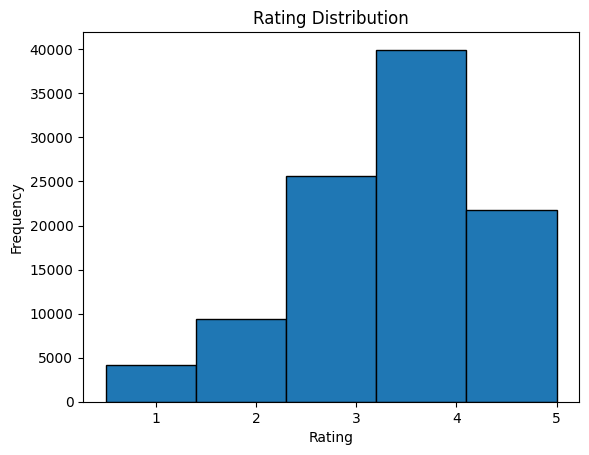

In [13]:
bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
plt.hist(data['rating'], bins=5, edgecolor='black')
plt.xticks([1, 2, 3, 4, 5])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [14]:
data['genres'] = data['genres'].astype('category').cat.codes

In [15]:
X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_reg, test_size=0.2, random_state=42)

In [17]:
reg = RandomForestRegressor()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(0.9668517662299426)

In [19]:
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)
y_cls = data['rating_class']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_cls, test_size=0.2, random_state=42)

In [21]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred_cls = clf.predict(X_test)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred_cls))

Accuracy: 0.6587167790559302


In [23]:
print(classification_report(y_test, y_pred_cls))

              precision    recall  f1-score   support

           0       0.57      0.51      0.54      7829
           1       0.71      0.75      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.63     20168
weighted avg       0.65      0.66      0.66     20168

